In [1]:
import datetime
import json
import logging
import math
import os
import sys
from abc import ABC, abstractmethod
from timeit import default_timer as timer

import numpy as np
from numba import njit
import matplotlib.pyplot as plt 
from scipy.interpolate import CubicSpline

from gtsimulation.Algos import BunemanBorisSimulator
from gtsimulation import functions
from gtsimulation.ElectricFields import GeneralFieldE
from gtsimulation.Global import Constants, Units, Regions, BreakCode, BreakIndex, SaveCode, SaveDef, BreakDef, vecRotMat
from gtsimulation.Interaction import NuclearInteraction, G4Decay, SynchCounter, RadLossStep
from gtsimulation.MagneticFields import AbsBfield
from gtsimulation.MagneticFields.Magnetosphere import Functions, Additions
from gtsimulation.Medium import GTGeneralMedium
from gtsimulation.Particle import ConvertT2R, GetAntiParticle, Flux
from gtsimulation.Particle.Generators import Distributions, Spectrums

In [2]:
class dipole_field(AbsBfield):
    def __init__(self, m0: float) -> None:
        self.m0 = m0
        self.m_vector = np.array([0, 0, 1]) * m0
        self.use_meters = True
        self.use_tesla = True


    def CalcBfield(self, x, y, z):
        return self.__calc_bfield(x, y, z, self.m_vector)
    
    @staticmethod
    @njit(fastmath=True)
    def __calc_bfield(x, y, z, m_vector):
        r_mag2 = x**2 + y**2 + z**2
        r_mag = np.sqrt(r_mag2)
    
        if r_mag == 0.0:
            return np.zeros(3)
        
        dot_product = m_vector[0]*x + m_vector[1]*y + m_vector[2]*z
    
        factor1 = 3.0 * dot_product / (r_mag2 * r_mag2 * r_mag)  
        factor2 = 1.0 / (r_mag2 * r_mag)                       
    
        Bx = 1e-7 * (factor1 * x - factor2 * m_vector[0])
        By = 1e-7 * (factor1 * y - factor2 * m_vector[1])
        Bz = 1e-7 * (factor1 * z - factor2 * m_vector[2])
    
        return np.array([Bx, By, Bz])


    def UpdateState(self, newDate):
        pass

    def to_string(self):
        s = f"""{self.__name__}
        Type: Magnetic Field
        Version: 1.0"""

        return s

In [4]:
dt = 1e-9
n_steps = 1e2

In [5]:
m0 = 0.5e30 #амплитуда момента магнитного поля
border = 1000000
R_star = 10000
step = {"UseAdaptiveStep": True, "InitialStep": 1}
radLosses = [True, {"Photons": True, "MinE": Units.GeV, "MaxE": 1e20}]

In [10]:
T = 10 * Units.TeV
latitude = 45
r_0 = np.array([np.cos(latitude), 0, np.sin(latitude)]) * R_star
v_0 = np.array([np.cos(latitude), 0, np.sin(latitude)])

particle = Flux(
    Spectrum=Spectrums.Monolines(energy=T),
    Distribution=Distributions.UserInput(
        R0=r_0,
        V0=v_0
    ),
    Names="e-",
    Nevents=1
)

b_field = dipole_field(m0)

simulator = BunemanBorisSimulator(
    Bfield=b_field,
    Region=Regions.Undefined,
    Medium=None,
    Particles=particle,
    InteractNUC=None,
    UseDecay=False,
    Date=datetime.datetime(2000, 1, 1),
    Step=step,
    Num=n_steps,
    ForwardTrck=1,
    Save=[1, {"Coordinates": True, "Velocities": True, "Energy": True}],
    Output=None,
    Verbose=2,
    BreakCondition={"Rmax": border},
    RadLosses=radLosses
)


Creating simulator object...
Date: 2000-01-01 00:00:00
Using adaptive time step: True
Initial time step: 1.000000 seconds
Min steps per Larmor radius: 600
Max steps per Larmor radius: 600
Number of steps: 100
Radiation Losses: True
Synchrotron Emission: True
Region: Undefined
		Additional Energy Losses: False
Number of files: 1
Output file name: None_num.npy
Save every 1 step of:
	Coordinates: True
	Velocities: True
	Efield: False
	Bfield: False
	Angles: False
	Path: False
	Density: False
	Clock: False
	Energy: True
	PitchAngles: False
	LarmorRadii: False
	GuidingCenter: False
Electric field: None
Medium: None
Decay: False
Nuclear Interactions: None
Flux: 
        Number of particles: 1
        Particles: ['e-']
        V: Isotropic
        Spectrum: Monolines
        Energy: 10000000.0
        Distribution: User Input
        R0 shape: (1, 3)
        V0 shape: (1, 3)
Break Conditions:
	Xmin: 0.0
	Ymin: 0.0
	Zmin: 0.0
	Rmin: 0.0
	Dist2Path: 0.0
	Xmax: inf
	Ymax: inf
	Zmax: inf
	Rmax: 1

--- Logging error ---
Traceback (most recent call last):
  File "/usr/lib/python3.12/logging/__init__.py", line 1160, in emit
    msg = self.format(record)
          ^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/logging/__init__.py", line 999, in format
    return fmt.format(record)
           ^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/logging/__init__.py", line 703, in format
    record.message = record.getMessage()
                     ^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/logging/__init__.py", line 392, in getMessage
    msg = msg % self.args
          ~~~~^~~~~~~~~~~
  File "/home/hagib/Templates/gt_env/lib/python3.12/site-packages/gtsimulation/MagneticFields/magnetic_field.py", line 45, in __str__
    return self.to_string()
           ^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_91852/4104578563.py", line 37, in to_string
    s = f"""{self.__name__}
             ^^^^^^^^^^^^^
AttributeError: 'dipole_field' object has no attribute '__name__'. Did you mean: '__ne__'?
Cal

In [9]:
track = simulator()[0][0]

Launching simulation...

File 1/1 started

Event 1/1 started
Particle: gamma (M = 0.000000 [MeV/c2], Z = 0)
Energy: 10000000.000000 [MeV], Rigidity: inf [GV]
Coordinates: [5253.21988818    0.         8509.03524534] [m]
Velocity: [0.52532199 0.         0.85090352]
Beta: 1.0
Beta * dt: 29979245800.000000 [m]
Calculating:


ZeroDivisionError: division by zero

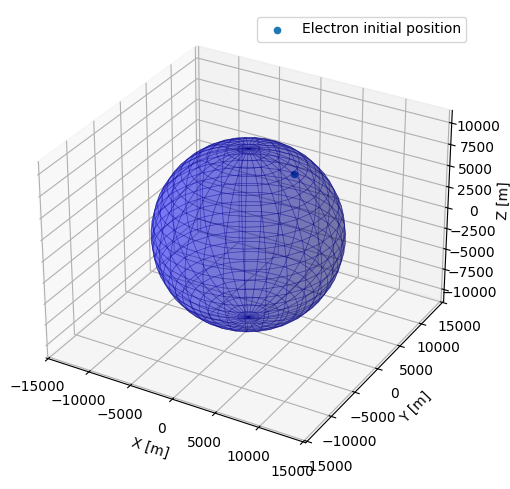

In [7]:
r = track["Track"]["Coordinates"]
v = track["Track"]["Velocities"]
e = track["Track"]["Energy"]

fig = plt.figure(figsize=(12, 6))

ax3d = fig.add_subplot(projection='3d')

ax3d.plot(*r.T)


ax3d.scatter(*r[0], label='Electron initial position')

radius = R_star
x_center, y_center, z_center = 0.0, 0.0, 0.0

u = np.linspace(0, 2 * np.pi, 30)
p = np.linspace(0, np.pi, 30) 

x = x_center + radius * np.outer(np.cos(u), np.sin(p))
y = y_center + radius * np.outer(np.sin(u), np.sin(p))
z = z_center + radius * np.outer(np.ones(np.size(u)), np.cos(p))

ax3d.plot_surface(x, y, z, color='b', alpha=0.3, edgecolor='navy', linewidth=0.5)


ax3d.set_xlabel("X [m]")
ax3d.set_ylabel("Y [m]")
ax3d.set_zlabel("Z [m]")
ax3d.axis('equal')

ax3d.legend()



#ax2d = fig.add_subplot(2, 1, 2)
#ax2d.plot(e)

plt.show()

In [8]:
photons = track['Child']
print(photons[0])

{'Track': {'Coordinates': array([5.25312307e+03, 4.54255495e-04, 8.50887843e+03]), 'Velocities': array([ 0.5253491 , -0.00492958,  0.85087251])}, 'Particle': {'PDG': 22, 'M': 0, 'T': np.float64(1425350.3419806673), 'Gen': 2}}


In [23]:
e = np.array(list(map(lambda x: x['Particle']['T'], photons)))

In [2]:
with np.load("./sqa_lookup_table.npz") as data:
    chi_grid = data['chi']
    table_values = data['values']

get_sqa_integral_part = CubicSpline(np.log10(chi_grid), table_values, extrapolate=False)

In [4]:
def get_pair_production_rate(T, r, v, polarization_mode, B_vector):
    MASS_E_C2 = 0.51099895069 * Unit.MeV
    B_crit = 4.414e13  # Критическое поле в Гауссах
    a = 7.2973525643e-3 # Постоянная тонкой структуры
    l = 3.8615926744e-13 # Приведенная комптонвская длина волны [m]

    
    # 1. Получаем параметры локального магнитного поля
    B_abs = np.linalg.norm(B_vector)
    
    # 2. Определяем угол между направлением фотона и линиями поля
    cos_theta = np.clip(np.dot(v, B_vector) / (np.linalg.norm(v) * B_abs), -1.0, 1.0)
    sin_theta = np.sqrt(1 - cos_theta ** 2)
    
    # 3. Проверка порога реакции
    # В любой системе отсчета порог: w * sin(theta) >= 2 * m_e * c^2
    threshold_energy = 2 * MASS_E_C2 / sin_theta
    if T < threshold_energy:
        return 0.0  # Реакция кинематически невозможна

    # 4. Вычисление безразмерного параметра chi (магнитная жесткость)
    chi = (T / (2 * MASS_E_C2)) * (B_abs / B_crit) * sin_theta

    if chi < 0.1:
        # 5. Вычисляем по экспонициальному приближению
        R = 0.23 * (a / l) * (B_abs * sin_theta) / B_crit * np.exp((-4/(3*chi)))
    elif chi > 10:
        # 6. Вычисляем по степеному приближению
        factor = a * (MASS_E_C2 ** 2) / (np.pi * T)
        R = factor * (1.19 * (chi ** (2/3)) - 2*np.pi/3)
    else:
        I = get_sqa_integral_part(chi)
        R = (a * (MASS_E_C2 ** 2) / (5.196152423 * np.pi * T)) * I

    return R

In [3]:
from PhotonSimulator import PhotonSimulator

T = 10
latitude = 45
r_0 = np.array([np.cos(latitude), 0, np.sin(latitude)]) * 0
v_0 = np.array([np.cos(latitude), 0, np.sin(latitude)])

ph = Flux(
    Spectrum=Spectrums.Monolines(energy=T),
    Distribution=Distributions.UserInput(
        R0=r_0,
        V0=v_0
    ),
    PDGcode=22,
    Nevents=1
)

b_field = dipole_field(0)

sim = PhotonSimulator(
    Bfield=b_field,
    Particles=ph,
    Step=1,
    Num=100,
    Save=[1, {"Coordinates": True, "Velocities": True, "Energy": True}],
    Verbose=2,
    PMConversion=True,
)

Creating simulator object...
Time step: 1 seconds
Number of steps: 100
Number of files: 1
Output file name: None_num.npy
Save every 1 step of:
	Coordinates: True
	Velocities: True
	Efield: False
	Bfield: False
	Angles: False
	Path: False
	Density: False
	Clock: False
	Energy: True
	PitchAngles: False
	LarmorRadii: False
	GuidingCenter: False
Flux: 
        Number of particles: 1
        V: Isotropic
        Spectrum: Monolines
        Energy: 10
        Distribution: User Input
        R0 shape: (1, 3)
        V0 shape: (1, 3)
Tracing: Inward
Using photon in magnetic field conversion


--- Logging error ---
Traceback (most recent call last):
  File "/usr/lib/python3.12/logging/__init__.py", line 1160, in emit
    msg = self.format(record)
          ^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/logging/__init__.py", line 999, in format
    return fmt.format(record)
           ^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/logging/__init__.py", line 703, in format
    record.message = record.getMessage()
                     ^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/logging/__init__.py", line 392, in getMessage
    msg = msg % self.args
          ~~~~^~~~~~~~~~~
  File "/home/hagib/Templates/gt_env/lib/python3.12/site-packages/gtsimulation/MagneticFields/magnetic_field.py", line 45, in __str__
    return self.to_string()
           ^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_167962/4104578563.py", line 37, in to_string
    s = f"""{self.__name__}
             ^^^^^^^^^^^^^
AttributeError: 'dipole_field' object has no attribute '__name__'. Did you mean: '__ne__'?
Ca

Break Conditions:
	Xmin: 0.0
	Ymin: 0.0
	Zmin: 0.0
	Rmin: 0.0
	Dist2Path: 0.0
	Xmax: inf
	Ymax: inf
	Zmax: inf
	Rmax: inf
	MaxPath: inf
	MaxTime: inf
	MaxRev: inf
	Death: inf
BC center: [0 0 0]
Simulator object created!



In [4]:
sim()

Launching simulation...

File 1/1 started

Event 1/1 started
Particle: gamma (M = 0.000000 [MeV/c2], Z = 0)
Energy: 10.000000 [MeV], Rigidity: inf [GV]
Coordinates: [0. 0. 0.] [m]
Velocity: [0.52532199 0.         0.85090352]
Beta: 1.0
Beta * dt: 29979245800.000000 [m]
Calculating:


/home/hagib/Projects/Pulsar-Antiparticles/PhotonSimulator.py:561: RuntimeWarning: invalid value encountered in scalar divide
  cos_theta = np.clip(np.dot(V, B) / (np.linalg.norm(V) * B_abs), -1.0, 1.0)


	Progress: 0%
	Progress: 10%
	Progress: 20%
	Progress: 30%
	Progress: 40%
	Progress: 50%
	Progress: 60%
	Progress: 70%
	Progress: 80%
	Progress: 90%
	Progress: 100%
Event 1/1 finished in 0.902 seconds

Simulation completed!


/home/hagib/Projects/Pulsar-Antiparticles/PhotonSimulator.py:561: RuntimeWarning: invalid value encountered in scalar divide
  cos_theta = np.clip(np.dot(V, B) / (np.linalg.norm(V) * B_abs), -1.0, 1.0)


[[{'Track': {'Coordinates': array([[0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
           [1.57487570e+10, 0.00000000e+00, 2.55094459e+10],
           [3.14975141e+10, 0.00000000e+00, 5.10188918e+10],
           [4.72462711e+10, 0.00000000e+00, 7.65283377e+10],
           [6.29950281e+10, 0.00000000e+00, 1.02037784e+11],
           [7.87437851e+10, 0.00000000e+00, 1.27547230e+11],
           [9.44925422e+10, 0.00000000e+00, 1.53056675e+11],
           [1.10241299e+11, 0.00000000e+00, 1.78566121e+11],
           [1.25990056e+11, 0.00000000e+00, 2.04075567e+11],
           [1.41738813e+11, 0.00000000e+00, 2.29585013e+11],
           [1.57487570e+11, 0.00000000e+00, 2.55094459e+11],
           [1.73236327e+11, 0.00000000e+00, 2.80603905e+11],
           [1.88985084e+11, 0.00000000e+00, 3.06113351e+11],
           [2.04733841e+11, 0.00000000e+00, 3.31622797e+11],
           [2.20482598e+11, 0.00000000e+00, 3.57132243e+11],
           [2.36231355e+11, 0.00000000e+00, 3.82641689e+11],
